# E4 - Experimento de Arquitetura: Variação de Profundidade da CNN

**Hipótese:** Adicionar uma terceira camada convolucional (Conv2D 128 filtros) permite que a rede aprenda representações hierárquicas mais ricas, melhorando a capacidade de discriminação entre classes.

**Variável independente:** Profundidade da rede (número de blocos Conv2D)
- Baseline: 2 blocos Conv [32, 64]
- Deeper: 3 blocos Conv [32, 64, 128]

**Variáveis controladas:** Todos os demais hiperparâmetros mantidos iguais ao baseline (lr=0.001, batch=32, epochs=50, dropout, L2).

In [1]:
# Setup: adiciona raiz do projeto ao path
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mateus/Projetos/Academico/Inteli/g01


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.models.experiment_runner import ExperimentRunner
from src.models.cnn_config import load_config, list_available_configs

print(f"TensorFlow: {tf.__version__}")
print(f"Configs disponíveis: {list_available_configs()}")

TensorFlow: 2.20.0
Configs disponíveis: ['baseline', 'deeper_arch', 'higher_dropout', 'l2batch', 'l2batch128', 'l2batch32']


## 1. Comparação das Arquiteturas

Antes de treinar, vamos comparar a estrutura dos dois modelos.

In [3]:
# Carregar configs para comparação
baseline_cfg = load_config('baseline')
deeper_cfg = load_config('deeper_arch')

print('=== Comparação de Configurações ===')
print(f"{'Parâmetro':<25} {'Baseline':<20} {'Deeper Arch':<20}")
print('-' * 65)
print(f"{'Filtros Conv':<25} {str(baseline_cfg['model']['filters']):<20} {str(deeper_cfg['model']['filters']):<20}")
print(f"{'Num blocos Conv':<25} {len(baseline_cfg['model']['filters']):<20} {len(deeper_cfg['model']['filters']):<20}")
print(f"{'Kernel size':<25} {baseline_cfg['model']['kernel_size']:<20} {deeper_cfg['model']['kernel_size']:<20}")
print(f"{'Dense units':<25} {baseline_cfg['model']['dense_units']:<20} {deeper_cfg['model']['dense_units']:<20}")
print(f"{'L2 regularizer':<25} {baseline_cfg['model']['l2_regularizer']:<20} {deeper_cfg['model']['l2_regularizer']:<20}")
print(f"{'Conv dropout':<25} {baseline_cfg['model']['conv_dropout_rate']:<20} {deeper_cfg['model']['conv_dropout_rate']:<20}")
print(f"{'Dense dropout':<25} {baseline_cfg['model']['dense_dropout_rate']:<20} {deeper_cfg['model']['dense_dropout_rate']:<20}")
print(f"{'Batch size':<25} {baseline_cfg['training']['batch_size']:<20} {deeper_cfg['training']['batch_size']:<20}")
print(f"{'Learning rate':<25} {baseline_cfg['training']['learning_rate']:<20} {deeper_cfg['training']['learning_rate']:<20}")
print(f"{'Epochs':<25} {baseline_cfg['training']['epochs']:<20} {deeper_cfg['training']['epochs']:<20}")

=== Comparação de Configurações ===
Parâmetro                 Baseline             Deeper Arch         
-----------------------------------------------------------------
Filtros Conv              [32, 64]             [32, 64, 128]       
Num blocos Conv           2                    3                   
Kernel size               3                    3                   
Dense units               128                  128                 
L2 regularizer            0.001                0.001               
Conv dropout              0.2                  0.2                 
Dense dropout             0.5                  0.5                 
Batch size                32                   32                  
Learning rate             0.001                0.001               
Epochs                    50                   50                  


In [4]:
# Visualizar arquitetura do modelo deeper
from src.models.cnn_builder import build_deep_cnn_model

model_deeper = build_deep_cnn_model(
    input_shape=(128, 128, 9),
    n_classes=2,
    filters_list=[32, 64, 128],
    kernel_size=(3, 3),
    l2_regularizer=0.001,
    conv_dropout_rate=0.2,
    dropout_rate=0.5,
    dense_units=128,
)

print('\n=== Arquitetura Deeper (3 blocos Conv) ===')
model_deeper.summary()


=== Arquitetura Deeper (3 blocos Conv) ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv1 (Dropout)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv2 (Dropout)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv3 (Dropout)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_3 (MaxPooling2D)   │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,666 (16.36 MB)

 Trainable params: 4,289,666 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Execução do Experimento E4

In [5]:
# Executar experimento com arquitetura mais profunda
runner = ExperimentRunner('deeper_arch')
result_e4 = runner.run_full_pipeline(verbose=1)

print('\n=== Resultado E4 ===')
for k, v in result_e4.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

✓ ExperimentRunner inicializado com config: deeper_arch
  Configurações disponíveis: ['baseline', 'deeper_arch', 'higher_dropout', 'l2batch', 'l2batch128', 'l2batch32']

EXPERIMENTO: deeper_arch

📂 Carregando dados...
✓ Dados carregados: (295, 128, 128, 9), labels: (295,)
  Classes: [0 1], distribuição: [179 116]

🏗️ Construindo modelo...
✓ Modelo compilado!

💾 Experimento: deeper_arch_20260312_094802

🚀 Iniciando treinamento...
  Batch size: 32
  Epochs: 50
  Learning rate: 0.001
  Train size: 236, Val size: 59
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.6059 - loss: 2.1963 - val_accuracy: 0.7288 - val_loss: 0.9080
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.7669 - loss: 0.9416 - val_accuracy: 0.7627 - val_loss: 0.9159
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.8263 - loss: 0.8243 - val_accuracy: 0.8305 - val_loss: 0.8001
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.8602 - loss: 0.7565 - val_accuracy: 0.77

## 3. Comparação E1 (Baseline) vs E4 (Deeper Arch)

In [6]:
# Carregar histórico do baseline mais recente para comparação
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'trained_models'

baseline_dirs = sorted(MODELS_DIR.glob('baseline_*'))
deeper_dirs = sorted(MODELS_DIR.glob('deeper_arch_*'))

if baseline_dirs:
    with open(baseline_dirs[-1] / 'history.json') as f:
        history_baseline = json.load(f)
    print(f'Baseline: {baseline_dirs[-1].name}')

if deeper_dirs:
    with open(deeper_dirs[-1] / 'history.json') as f:
        history_deeper = json.load(f)
    print(f'Deeper: {deeper_dirs[-1].name}')

Baseline: baseline_20260311_083736
Deeper: deeper_arch_20260312_094802


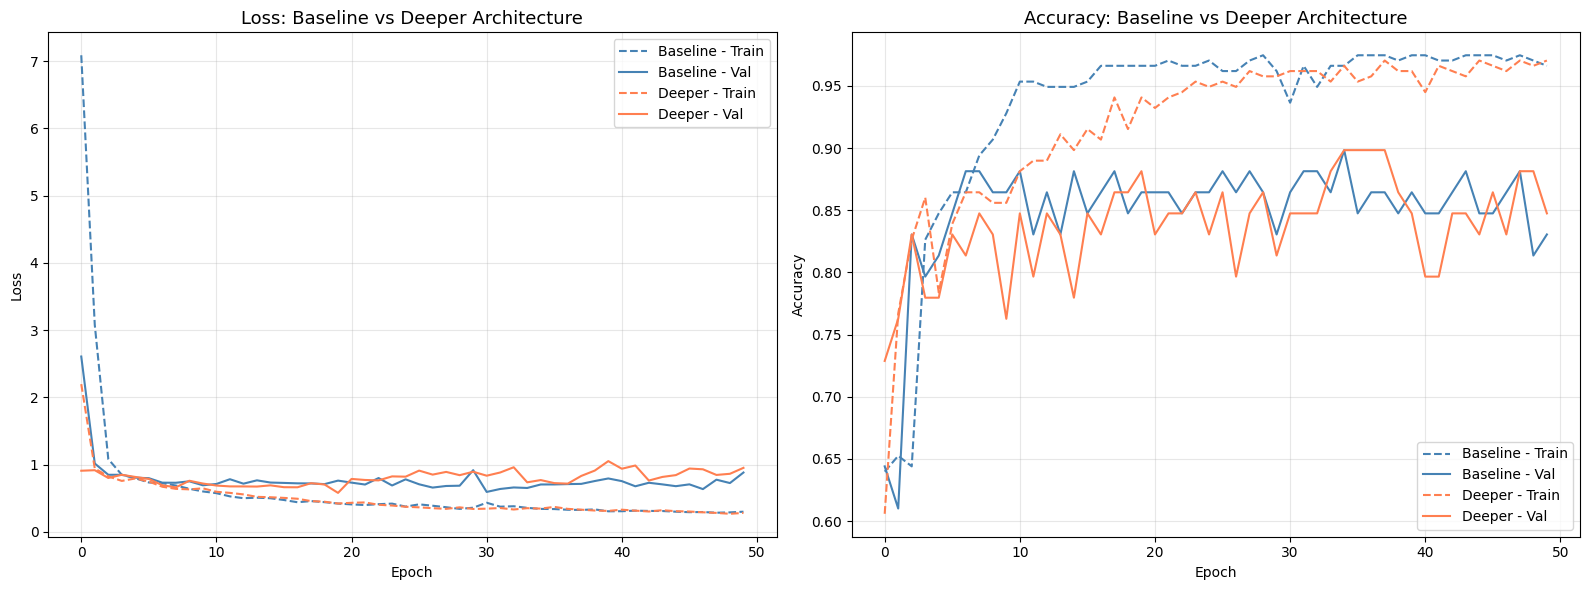

Gráfico salvo em outputs/trained_models/e4_learning_curves_comparison.png


In [7]:
# Curvas de aprendizado comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
ax = axes[0]
ax.plot(history_baseline['loss'], label='Baseline - Train', color='steelblue', linestyle='--')
ax.plot(history_baseline['val_loss'], label='Baseline - Val', color='steelblue')
ax.plot(history_deeper['loss'], label='Deeper - Train', color='coral', linestyle='--')
ax.plot(history_deeper['val_loss'], label='Deeper - Val', color='coral')
ax.set_title('Loss: Baseline vs Deeper Architecture', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(history_baseline['accuracy'], label='Baseline - Train', color='steelblue', linestyle='--')
ax.plot(history_baseline['val_accuracy'], label='Baseline - Val', color='steelblue')
ax.plot(history_deeper['accuracy'], label='Deeper - Train', color='coral', linestyle='--')
ax.plot(history_deeper['val_accuracy'], label='Deeper - Val', color='coral')
ax.set_title('Accuracy: Baseline vs Deeper Architecture', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'e4_learning_curves_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em outputs/trained_models/e4_learning_curves_comparison.png')

In [8]:
# Tabela comparativa de métricas finais
log_path = MODELS_DIR / 'experiments_log.csv'
df_log = pd.read_csv(log_path)

# Pegar última execução de cada config
baseline_row = df_log[df_log['config_name'] == 'baseline'].iloc[-1]
deeper_row = df_log[df_log['config_name'] == 'deeper_arch'].iloc[-1]

metrics_to_compare = [
    ('val_acc', 'Val Accuracy'),
    ('val_accuracy', 'Val Accuracy (sklearn)'),
    ('val_f1', 'F1-Score'),
    ('val_precision', 'Precision'),
    ('val_recall', 'Recall'),
    ('val_balanced_accuracy', 'Balanced Accuracy'),
    ('val_auc_roc', 'AUC-ROC'),
    ('val_sensitivity', 'Sensitivity'),
    ('val_specificity', 'Specificity'),
    ('train_loss', 'Train Loss'),
    ('val_loss', 'Val Loss'),
]

print(f"{'Métrica':<25} {'Baseline (E1)':<18} {'Deeper (E4)':<18} {'Delta':<12}")
print('=' * 73)
for col, name in metrics_to_compare:
    b_val = baseline_row.get(col, None)
    d_val = deeper_row.get(col, None)
    try:
        b_val = float(b_val)
        d_val = float(d_val)
        delta = d_val - b_val
        sign = '+' if delta >= 0 else ''
        print(f'{name:<25} {b_val:<18.4f} {d_val:<18.4f} {sign}{delta:<12.4f}')
    except (TypeError, ValueError):
        print(f'{name:<25} {str(b_val):<18} {str(d_val):<18} {"N/A":<12}')

Métrica                   Baseline (E1)      Deeper (E4)        Delta       
Val Accuracy              0.8305             0.8475             +0.0169      
Val Accuracy (sklearn)    0.8305             0.8475             +0.0169      
F1-Score                  0.8341             0.8494             +0.0153      
Precision                 0.8681             0.8558             -0.0123     
Recall                    0.8305             0.8475             +0.0169      
Balanced Accuracy         0.8578             0.8496             -0.0081     
AUC-ROC                   0.7155             0.6040             -0.1115     
Sensitivity               0.9524             0.8571             -0.0952     
Specificity               0.7632             0.8421             +0.0789      
Train Loss                0.2987             0.2808             -0.0179     
Val Loss                  0.8814             0.9509             +0.0696      


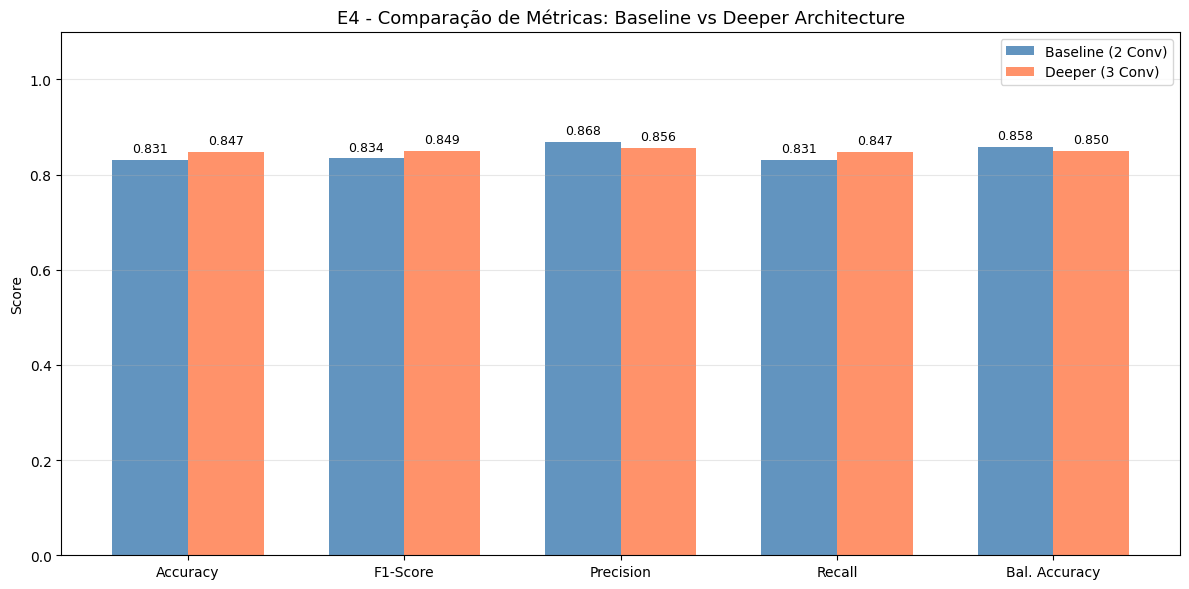

Gráfico salvo em outputs/trained_models/e4_metrics_comparison.png


In [9]:
# Gráfico de barras comparativo
metrics_for_plot = ['val_accuracy', 'val_f1', 'val_precision', 'val_recall', 'val_balanced_accuracy']
metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'Bal. Accuracy']

baseline_vals = [float(baseline_row.get(m, 0)) for m in metrics_for_plot]
deeper_vals = [float(deeper_row.get(m, 0)) for m in metrics_for_plot]

x = np.arange(len(metric_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, baseline_vals, w, label='Baseline (2 Conv)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, deeper_vals, w, label='Deeper (3 Conv)', color='coral', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('E4 - Comparação de Métricas: Baseline vs Deeper Architecture', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'e4_metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em outputs/trained_models/e4_metrics_comparison.png')

In [10]:
# Análise de overfitting comparativa
print('=== Análise de Overfitting ===')
print()

for name, hist in [('Baseline', history_baseline), ('Deeper', history_deeper)]:
    final_train_acc = hist['accuracy'][-1]
    final_val_acc = hist['val_accuracy'][-1]
    final_train_loss = hist['loss'][-1]
    final_val_loss = hist['val_loss'][-1]
    acc_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss
    best_val_epoch = int(np.argmax(hist['val_accuracy'])) + 1
    best_val_acc = max(hist['val_accuracy'])
    
    print(f'--- {name} ---')
    print(f'  Train acc: {final_train_acc:.4f} | Val acc: {final_val_acc:.4f} | Gap: {acc_gap:.4f}')
    print(f'  Train loss: {final_train_loss:.4f} | Val loss: {final_val_loss:.4f} | Gap: {loss_gap:.4f}')
    print(f'  Melhor val_acc: {best_val_acc:.4f} (epoch {best_val_epoch})')
    print()

=== Análise de Overfitting ===

--- Baseline ---
  Train acc: 0.9661 | Val acc: 0.8305 | Gap: 0.1356
  Train loss: 0.2987 | Val loss: 0.8814 | Gap: 0.5827
  Melhor val_acc: 0.8983 (epoch 35)

--- Deeper ---
  Train acc: 0.9703 | Val acc: 0.8475 | Gap: 0.1229
  Train loss: 0.2808 | Val loss: 0.9509 | Gap: 0.6702
  Melhor val_acc: 0.8983 (epoch 35)



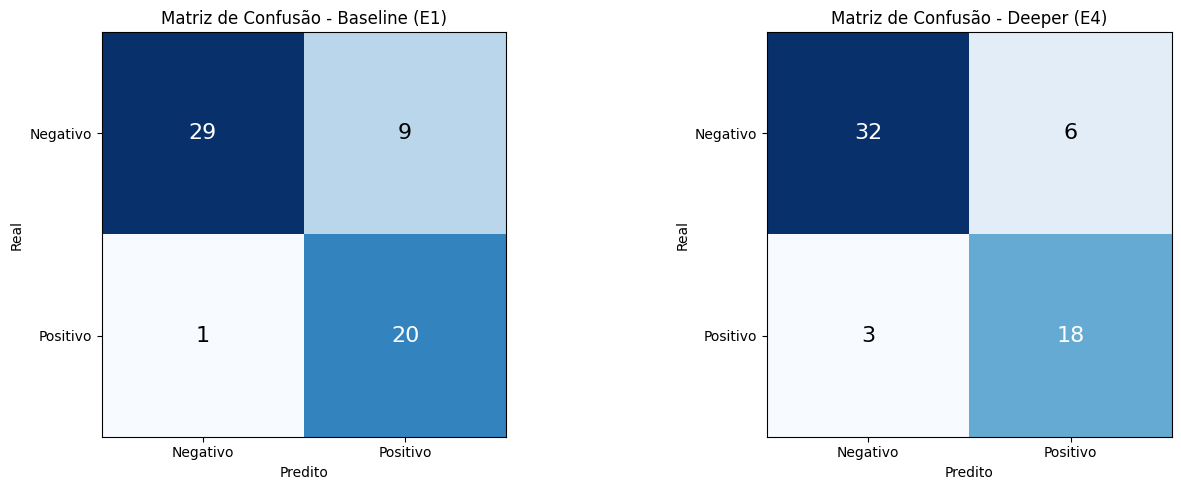

In [11]:
# Matriz de confusão comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, row) in zip(axes, [('Baseline (E1)', baseline_row), ('Deeper (E4)', deeper_row)]):
    tp = int(row.get('val_cm_tp', 0))
    fp = int(row.get('val_cm_fp', 0))
    tn = int(row.get('val_cm_tn', 0))
    fn = int(row.get('val_cm_fn', 0))
    cm = np.array([[tn, fp], [fn, tp]])
    
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Matriz de Confusão - {name}', fontsize=12)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negativo', 'Positivo'])
    ax.set_yticklabels(['Negativo', 'Positivo'])
    
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=16)

plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'e4_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Conclusões do Experimento E4

### Resultado: resultados mistos - ganhos marginais em accuracy, perdas significativas em AUC-ROC e sensibilidade.

**Impacto da profundidade nas métricas:**
- Val Accuracy subiu marginalmente de 83.05% para 84.75% (+1.7pp)
- F1-Score subiu de 0.834 para 0.849 (+0.015)
- AUC-ROC caiu de 0.716 para 0.604 (-0.112) — calibração de probabilidades degradou
- Precision caiu levemente de 0.868 para 0.856 (-0.012)

**Sensibilidade vs Especificidade (trade-off):**
- Sensitivity caiu de 95.24% para 85.71% (-9.5pp) — FN subiu de 1 para 3
- Specificity subiu de 76.32% para 84.21% (+7.9pp) — FP caiu de 9 para 6
- O modelo deeper é mais conservador: erra menos nos negativos, mas perde mais positivos
- Para detecção ambiental, alta sensibilidade é preferível (não perder casos reais)

**Overfitting:**
- Gap accuracy: Deeper 0.123 vs Baseline 0.136 — levemente melhor
- Gap loss: Deeper 0.670 vs Baseline 0.583 — pior (val_loss mais alta)
- Melhor val_acc idêntica: 0.8983 no epoch 35 para ambos
- Val loss do deeper sobe consistentemente após epoch 13, atingindo 0.951 ao final

**Diagnóstico:**
- A 3a camada Conv (128 filtros) com MaxPool reduz o feature map de 32x32 para 16x16, potencialmente descartando informação espacial
- O gargalo Flatten (32.768) → Dense (128) é muito agressivo: 99.6% de compressão
- O modelo tem 4.3M params vs ~1.2M do baseline, mas com apenas 236 amostras de treino a capacidade extra não ajuda na generalização
- A queda em AUC-ROC sugere que o modelo produz probabilidades menos bem calibradas

**Recomendação:** Manter a arquitetura baseline (2 Conv) como referência. A profundidade adicional traz um trade-off desfavorável: ganho marginal em accuracy custa queda relevante em sensibilidade e AUC-ROC. Para investigar arquitetura futuramente, considerar: (a) Global Average Pooling em vez de Flatten, (b) BatchNormalization, ou (c) data augmentation para melhor aproveitamento de redes mais profundas.